## Классная работа

### nn.ConvTranspose2d

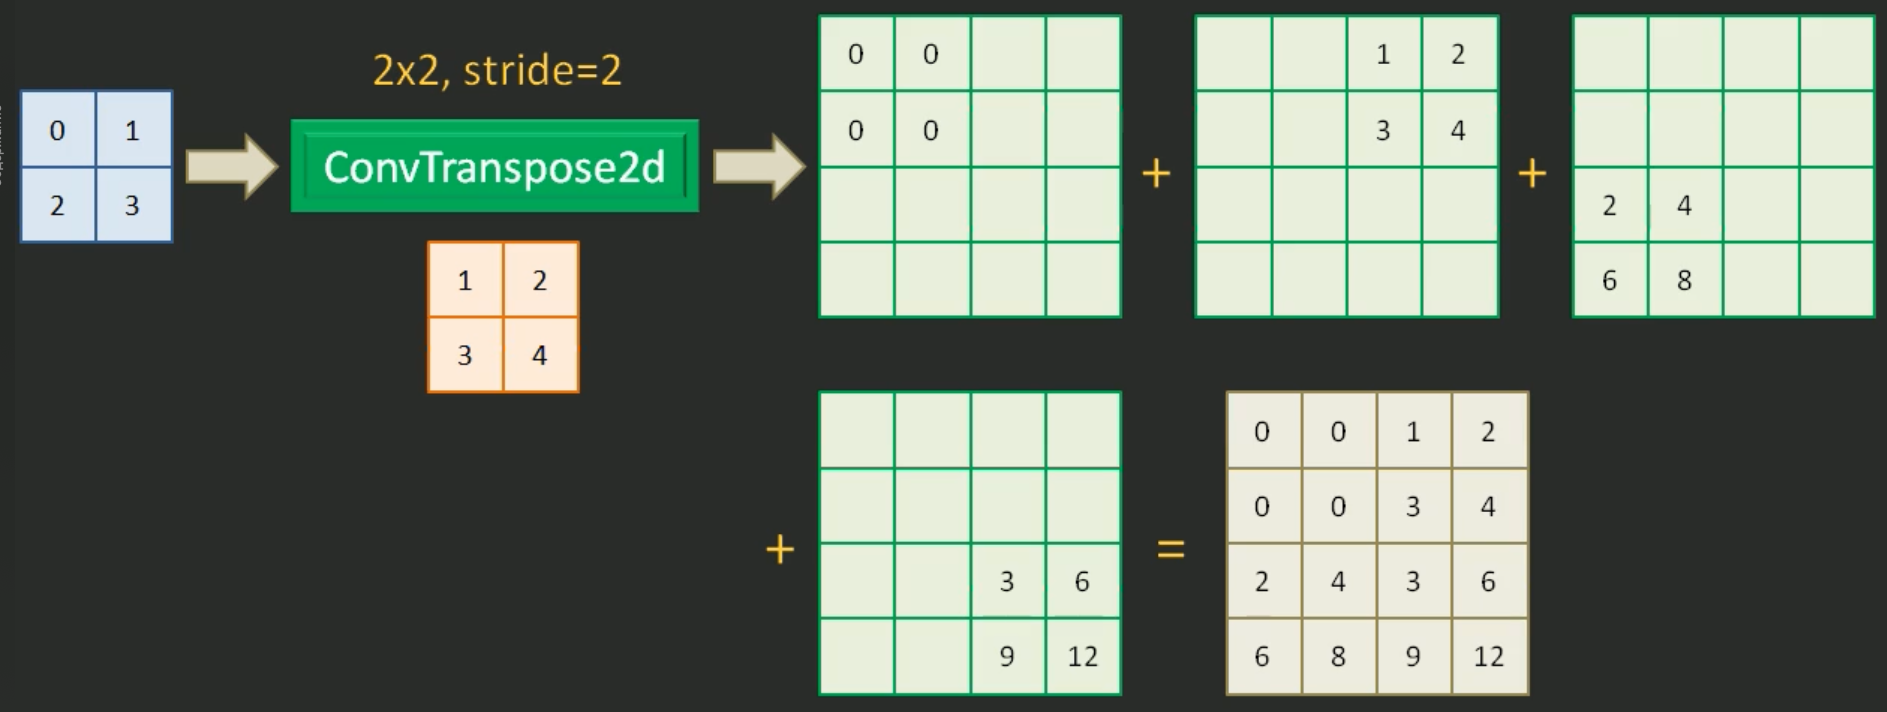

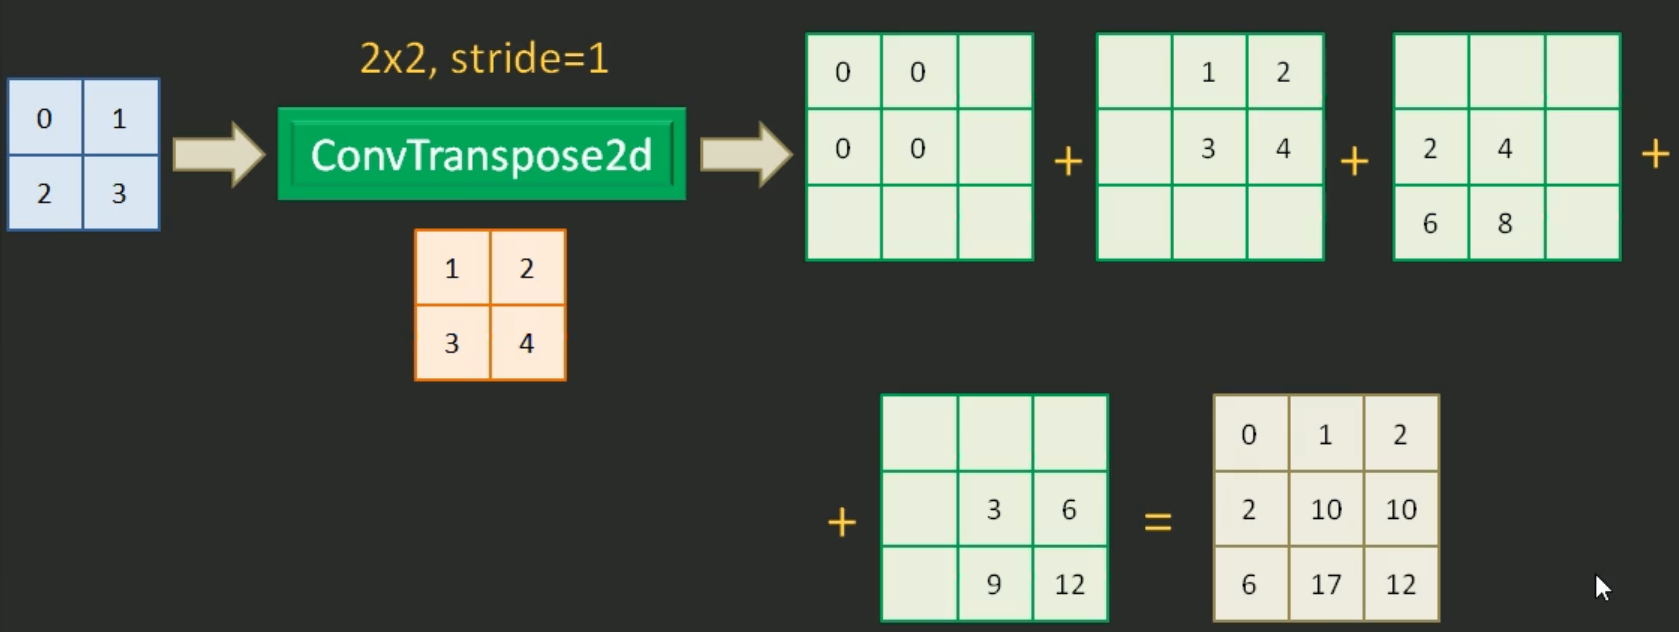

In [3]:
import torch.nn as nn
import torch

In [4]:
x = torch.tensor([[[0, 1], [2, 3]]], dtype=torch.float32)
w = torch.tensor([[[[1, 2], [3, 4]]]], dtype=torch.float32)
alg = nn.ConvTranspose2d(in_channels=1, out_channels=1, kernel_size=2, stride=2, bias=False)

In [5]:
st = alg.state_dict()
st['weight'] = w
alg.load_state_dict(st)

<All keys matched successfully>

In [6]:
y = alg(x)
y

tensor([[[ 0.,  0.,  1.,  2.],
         [ 0.,  0.,  3.,  4.],
         [ 2.,  4.,  3.,  6.],
         [ 6.,  8.,  9., 12.]]], grad_fn=<SqueezeBackward1>)

### Обучение нейросети

In [70]:
import torch.nn as nn
import torch.optim as optim
import torch

import torchvision.transforms.v2 as tfs_v2

import torch.utils.data as data

from torch.nn.parallel import DataParallel as DP
import torch.distributed as dist

import os
from PIL import Image
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

#### Создание класса датасета

In [3]:
class SegmentDataset(data.Dataset):
    def __init__(self, path, transform_img=None, transform_mask=None):
        self.path = path
        self.transform_img = transform_img
        self.transform_mask = transform_mask

        path = os.path.join(self.path, 'images')
        list_files = os.listdir(path)
        self.length = len(list_files)
        self.images = list(map(lambda _x: os.path.join(path, _x), list_files))

        path = os.path.join(self.path, 'masks')
        list_files = os.listdir(path)
        self.masks = list(map(lambda _x: os.path.join(path, _x), list_files))

    def __getitem__(self, item):
        path_img, path_mask = self.images[item], self.masks[item]
        img = Image.open(path_img).convert('RGB')
        mask = Image.open(path_mask).convert('L') # grayscale

        if self.transform_img:
            img = self.transform_img(img)

        if self.transform_mask:
            mask = self.transform_mask(mask)
            mask[mask < 250] = 1
            mask[mask >= 250] = 0

        return img, mask

    def __len__(self):
        return self.length

In [4]:
class UNetModel(nn.Module):
    class _TwoConvLayers(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.model = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
            )

        def forward(self, x):
            return self.model(x)

    class _EncoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.block = UNetModel._TwoConvLayers(in_channels, out_channels)
            self.max_pool = nn.MaxPool2d(2)

        def forward(self, x):
            x = self.block(x)
            y = self.max_pool(x)
            return y, x

    class _DecoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.transpose = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
            self.block = UNetModel._TwoConvLayers(in_channels, out_channels)

        def forward(self, x, y):
            x = self.transpose(x)
            u = torch.cat([x, y], dim=1)
            u = self.block(u)
            return u

    def __init__(self, in_channels=3, num_classes=1):
        super().__init__()
        self.enc_block1 = self._EncoderBlock(in_channels, 64)
        self.enc_block2 = self._EncoderBlock(64, 128)
        self.enc_block3 = self._EncoderBlock(128, 256)
        self.enc_block4 = self._EncoderBlock(256, 512)

        self.bottleneck = self._TwoConvLayers(512, 1024)

        self.dec_block1 = self._DecoderBlock(1024, 512)
        self.dec_block2 = self._DecoderBlock(512, 256)
        self.dec_block3 = self._DecoderBlock(256, 128)
        self.dec_block4 = self._DecoderBlock(128, 64)

        self.out = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        x, y1 = self.enc_block1(x)
        x, y2 = self.enc_block2(x)
        x, y3 = self.enc_block3(x)
        x, y4 = self.enc_block4(x)

        x = self.bottleneck(x)

        x = self.dec_block1(x, y4)
        x = self.dec_block2(x, y3)
        x = self.dec_block3(x, y2)
        x = self.dec_block4(x, y1)

        return self.out(x)

#### Класс ошибки

In [58]:
class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, targets, logits):
        num = targets.shape[0]
        probs = nn.functional.sigmoid(logits)

        m1 = targets.view(num, -1)
        m2 = probs.view(num, -1)

        interception = (m1 * m2).sum(dim=1)
        union = m1.sum(dim=1) + m2.sum(dim=1)

        inversed_score = (2 * interception + self.smooth) / (union + self.smooth)
        score = 1 - inversed_score.sum() / num

        return score

#### Обучение

In [82]:
tr_img = tfs_v2.Compose([tfs_v2.ToImage(), tfs_v2.ToDtype(torch.float32, scale=True)])
tr_mask = tfs_v2.Compose([tfs_v2.ToImage(), tfs_v2.ToDtype(torch.float32)])

In [83]:
d_train = SegmentDataset(r"/kaggle/input/datasets/egrsid/dataset-seg/dataset_seg", transform_img=tr_img, transform_mask=tr_mask)
train_data = data.DataLoader(d_train, batch_size=4, shuffle=True)

In [84]:
model = UNetModel().cuda()

optimizer = optim.RMSprop(params=model.parameters(), lr=0.001)
loss_1 = nn.BCEWithLogitsLoss().cuda()
loss_2 = SoftDiceLoss().cuda()

epochs = 10
model.train();

#### Распределяем обучение на 2 гпу

In [85]:
if torch.cuda.device_count() > 1:
    print("Training on 2 GPUs")
    model = DP(model)

Training on 2 GPUs


In [86]:
for _e in range(epochs):
    loss_mean = 0
    lm_count = 0

    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        x_train, y_train = x_train.cuda(), y_train.cuda()
        predict = model(x_train)
        loss = loss_1(predict, y_train) + loss_2(predict, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean:.3f}")

Epoch [10/10], loss_mean=1.161: 100%|██████████| 5/5 [00:02<00:00,  1.73it/s]


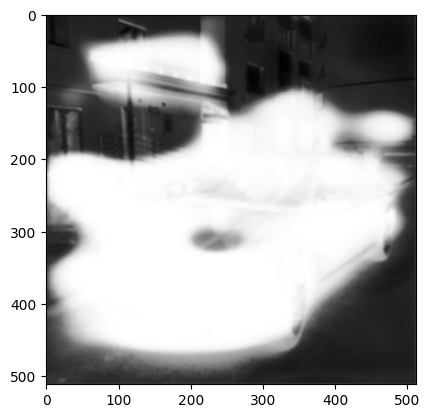

In [87]:
img = Image.open(r"/kaggle/input/datasets/egrsid/dataset-seg/dataset_seg/images/IMG_9208.jpg").convert('RGB')
img = tr_img(img).unsqueeze(0).cuda()

model.eval()
p = model(img).squeeze(0)
x = nn.functional.sigmoid(p.permute(1, 2, 0))
x = x.detach().cpu().numpy() * 255
x = np.clip(x, 0, 255).astype('uint8')
plt.imshow(x, cmap='gray')
plt.show()

### Домашняя работа

In [7]:
import torch
import torch.nn as nn

x = torch.tensor([[1, 2], [-3, 4]], dtype=torch.float32)
w = torch.tensor([[-1 ,2, 3], [1, -2, 1], [-3, 1, 4]], dtype=torch.float32)

upsample = nn.ConvTranspose2d(1, 1, (3, 3), 2, bias=False)
state_dict = upsample.state_dict()
state_dict['weight'] = w[None, None, ...]

upsample.load_state_dict(state_dict)

print(upsample(x.unsqueeze(0)).squeeze())

tensor([[ -1.,   2.,   1.,   4.,   6.],
        [  1.,  -2.,   3.,  -4.,   2.],
        [  0.,  -5., -15.,  10.,  20.],
        [ -3.,   6.,   1.,  -8.,   4.],
        [  9.,  -3., -24.,   4.,  16.]], grad_fn=<SqueezeBackward0>)


In [12]:
t = torch.zeros(5)
t.random_(0, 5)

tensor([0., 4., 1., 2., 3.])

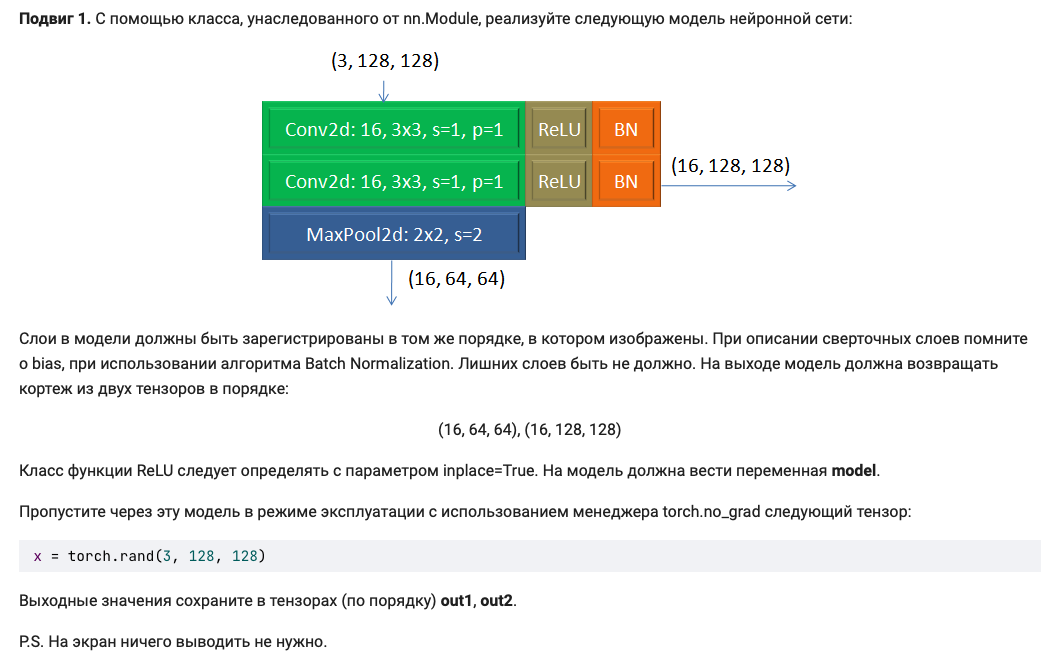

In [80]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели (обязательно до тензора x)
class BlockModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 16, 3, 1, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(16)
        )

    def forward(self, x):
        x = self.model(x)
        y = nn.MaxPool2d(2, stride=2)(x)

        return y, x
        
x = torch.rand(3, 128, 128) # тензор x в программе не менять

# здесь продолжайте программу
model = BlockModel()
model.eval()
out1, out2 = model(x.unsqueeze(0))

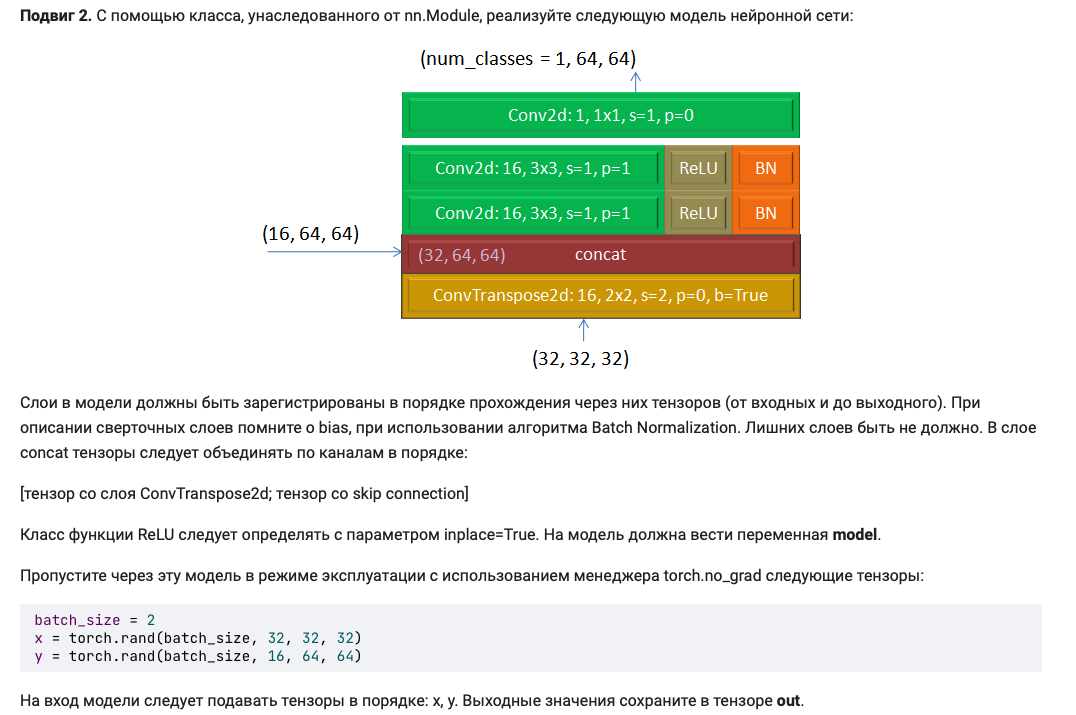

In [97]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели (обязательно до тензоров)
class BlockModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.transpose = nn.ConvTranspose2d(32, 16, 2, 2, 0, bias=True)
        self.block = nn.Sequential(
            nn.Conv2d(32, 16, 3, 1, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 16, 3, 1, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(16)
        )
        self.output = nn.Conv2d(16, 1, 1, stride=1, padding=0)

    def forward(self, y, x):
        transposed = self.transpose(y)
        x = torch.cat([transposed, x], dim=1)
        x = self.block(x)
        out = self.output(x)
        
        return out

# тензоры x, y в программе не менять
batch_size = 2
x = torch.rand(batch_size, 32, 32, 32)
y = torch.rand(batch_size, 16, 64, 64)

# здесь продолжайте программу
model = BlockModel()
model.eval()

with torch.no_grad():
    out = model(x, y)